In [2]:
# Генератор данных, удаление шума, удаление периодического шума
# Метрики: SSIM, MSE. Сравните изображения.
# Изображения в оттенках серого.
# Задача 3.1
# Выполните фильтрацию изображений при  помощи преобразования Фурье.
# Сравните результаты фильтрации с алгоритмами, реализованными в task 1.
# Задача 3.2 
# Обновите генератор, который Вы создали в task_1.
# Добавьте деградационный периодический шум (покомпонентноее умножение исходного и зашумленного изображения). н
# Выполните фильтрацию периодического шума при  помощи преобразования Фурье. 
# Оцените качество фильтрации.

In [ ]:
# Задача 3.1

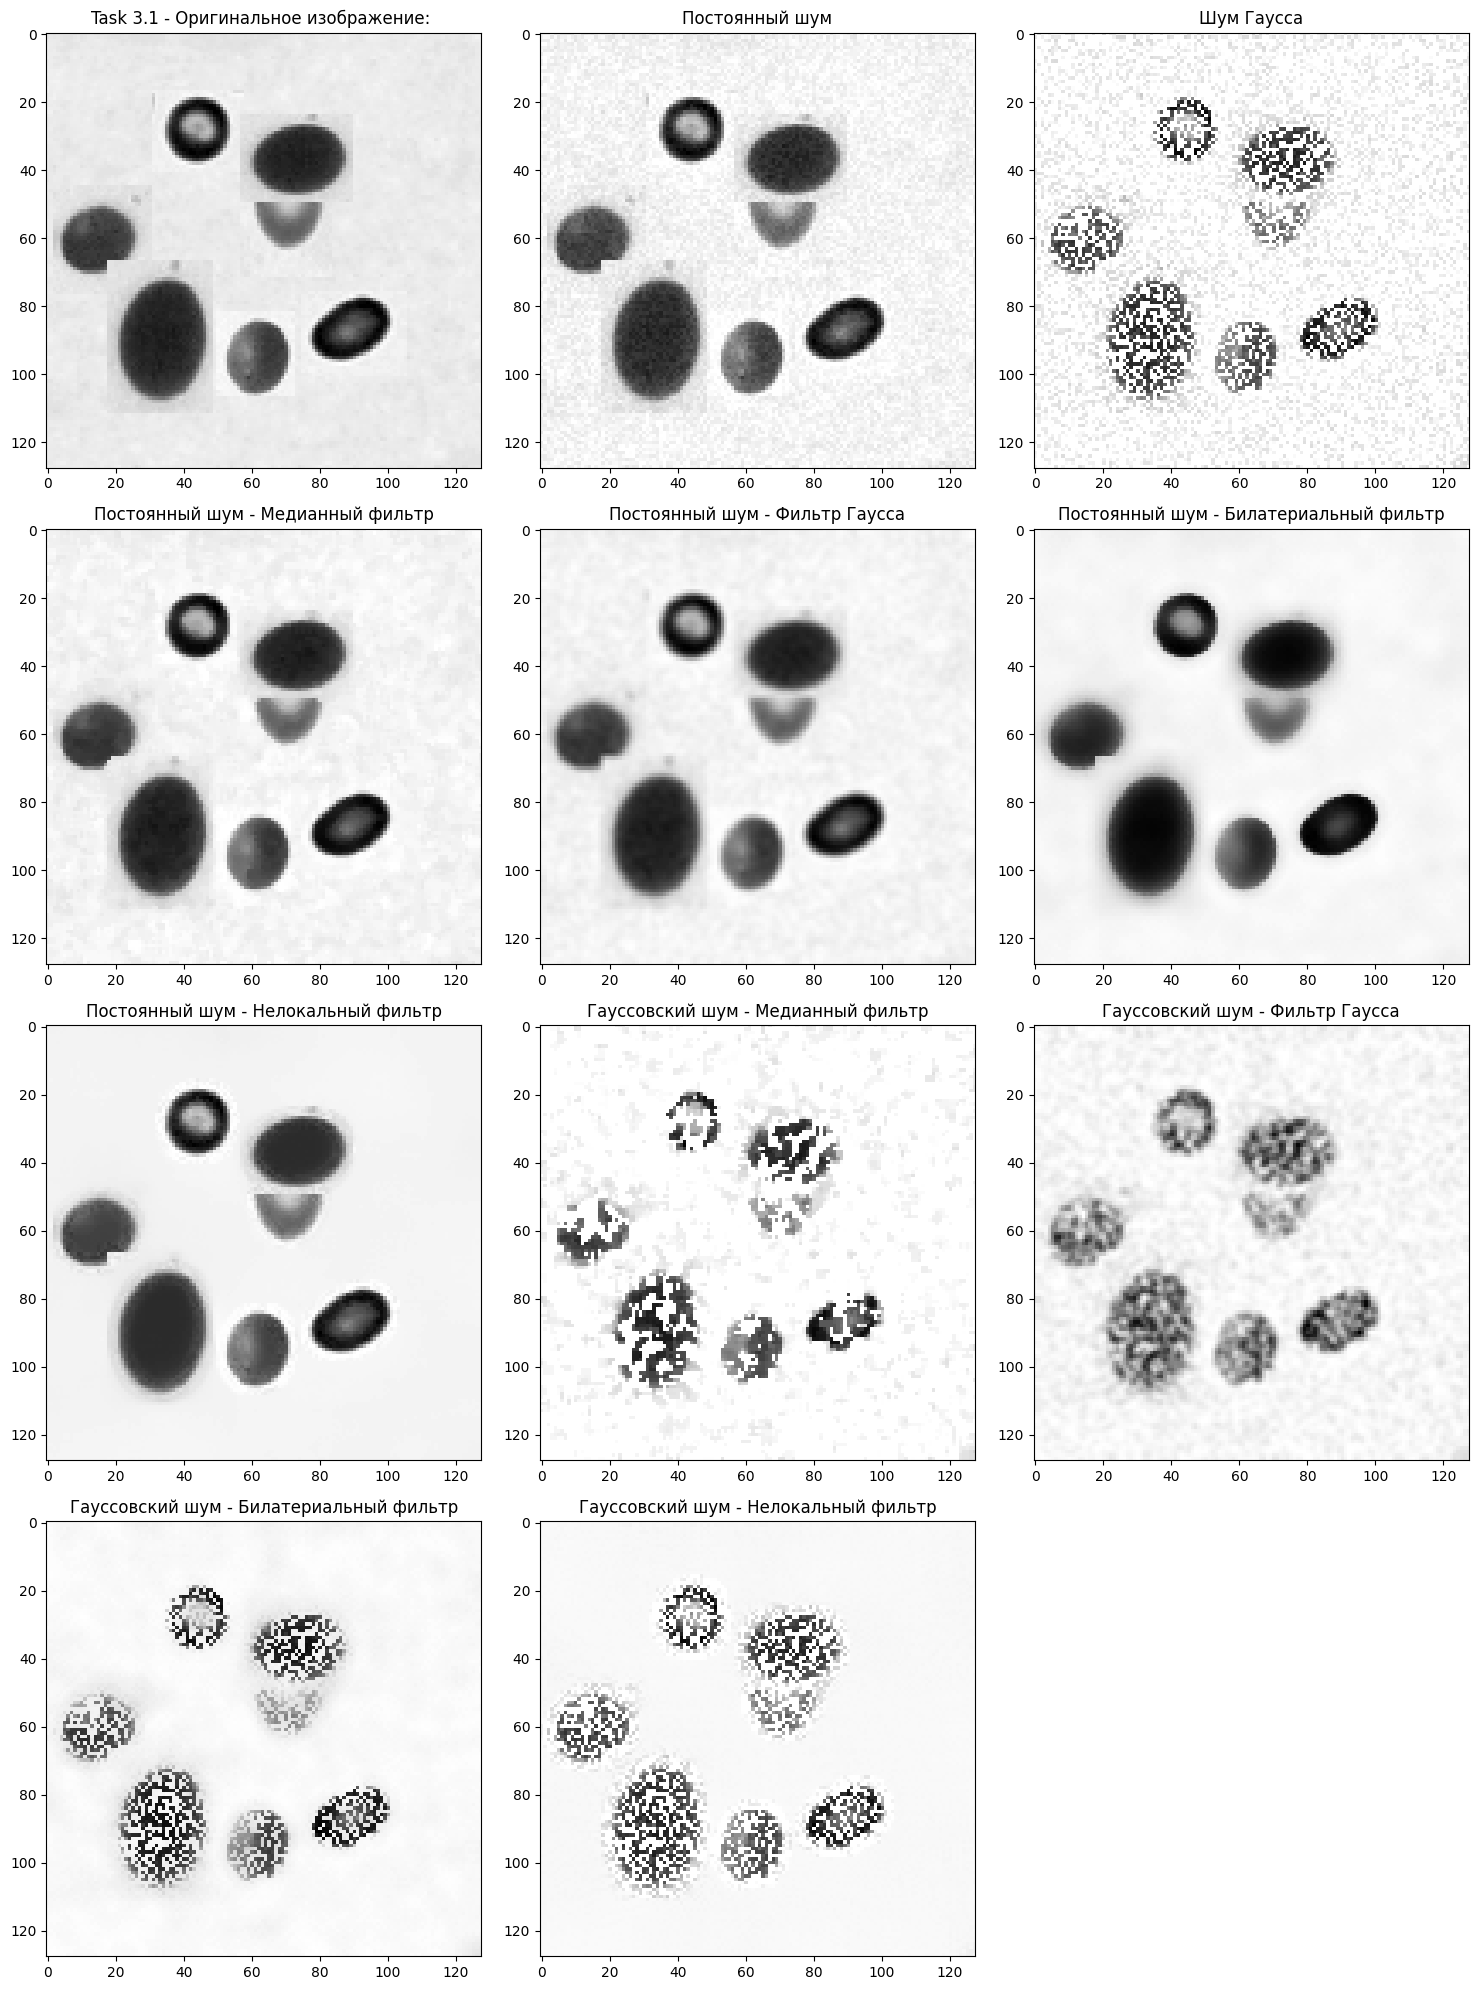


Метрики качества фильтрации для Task 3.1 - Оригинальное изображение:

Постоянный шум:
Медианный фильтр: MSE=405.50, SSIM=0.8934
Фильтр Гаусса: MSE=404.13, SSIM=0.9255
Билатериальный фильтр: MSE=422.05, SSIM=0.9074
Нелокальный фильтр: MSE=391.72, SSIM=0.9188

Лучший фильтр для постоянного шума: Нелокальный фильтр (MSE)



Гауссовский шум:
Медианный фильтр: MSE=3006.15, SSIM=0.5943
Фильтр Гаусса: MSE=2018.06, SSIM=0.7069
Билатериальный фильтр: MSE=2575.61, SSIM=0.7309
Нелокальный фильтр: MSE=2878.06, SSIM=0.7093

Лучший фильтр для гауссовского шума: Фильтр Гаусса (MSE)




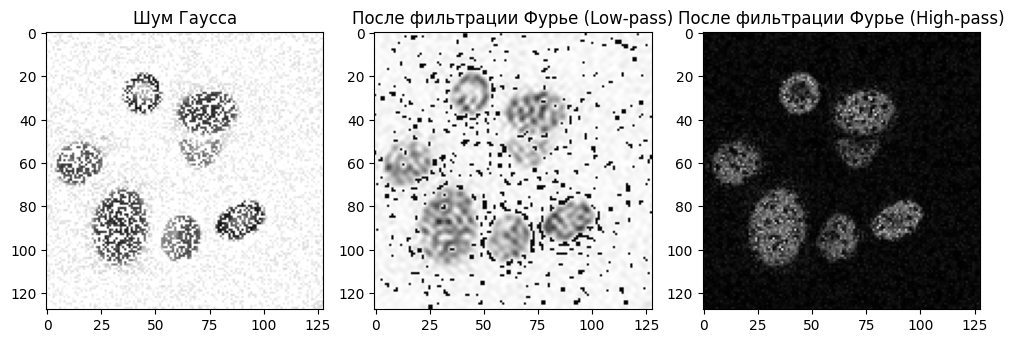

In [6]:
import os
import numpy as np
import cv2
import random
import time
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim, mean_squared_error
import math

fon_path = "/Users/zuhroabdulloeva/Desktop/4 КУРС/cv/blood_cells_dataset/fon/"
patch_path = "/Users/zuhroabdulloeva/Desktop/4 КУРС/cv/blood_cells_dataset/patch/"

fon_images = [cv2.imread(os.path.join(fon_path, f), cv2.IMREAD_GRAYSCALE) for f in os.listdir(fon_path) if f.endswith('.png')]
patch_images = [cv2.imread(os.path.join(patch_path, f), cv2.IMREAD_GRAYSCALE) for f in os.listdir(patch_path) if f.endswith('.png')]

def add_noise(image, noise_type="constant"):
    if noise_type == "constant":
        noise = np.random.randint(10, 30, image.shape, dtype=np.uint8)
        return cv2.add(image, noise)
    elif noise_type == "gaussian":
        mean = 0
        sigma = 25  # можно изменить на другие значения
        gauss = np.random.normal(mean, sigma, image.shape).astype(np.uint8)
        noisy = cv2.add(image, gauss)
        return noisy
    return image

def apply_filters_and_measure_time(image):
    filters = {}
    
    start_time = time.time()
    filters["Медианный фильтр"] = (cv2.medianBlur(image, 3), time.time() - start_time)

    start_time = time.time()
    filters["Фильтр Гаусса"] = (cv2.GaussianBlur(image, (3, 3), 0), time.time() - start_time)

    start_time = time.time()
    filters["Билатериальный фильтр"] = (cv2.bilateralFilter(image, 9, 75, 75), time.time() - start_time)

    start_time = time.time()
    filters["Нелокальный фильтр"] = (cv2.fastNlMeansDenoising(image, None, 10, 7, 21), time.time() - start_time)

    return filters

def fourier_filter(image, low_pass=True, cutoff_frequency=30):
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)

    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2

    mask = np.zeros((rows, cols))
    if low_pass:
        mask[crow - cutoff_frequency:crow + cutoff_frequency, ccol - cutoff_frequency:ccol + cutoff_frequency] = 1
    else:
        mask[:crow - cutoff_frequency, :] = 1
        mask[crow + cutoff_frequency:, :] = 1
        mask[:, :ccol - cutoff_frequency] = 1
        mask[:, ccol + cutoff_frequency:] = 1

    fshift *= mask

    f_ishift = np.fft.ifftshift(fshift)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    return np.uint8(img_back)

def evaluate_filters(original, noisy, filters):
    results = {}

    for name, (filtered, _) in filters.items():
        mse_value = mean_squared_error(original, filtered)
        min_dim = min(original.shape[:2]) 
        win_size = min(7, min_dim)  

        try:
            if win_size >= 7:
                ssim_value = ssim(original, filtered, full=True, win_size=win_size)[0]
            else:
                ssim_value = float('nan')
        except ValueError:
            ssim_value = float('nan')

        results[name] = (mse_value, ssim_value)

    return results

def generate_image():
    background = random.choice(fon_images).copy()
    image = background.copy()

    for _ in range(random.randint(5, 15)):  
        cell = random.choice(patch_images)
        cell = cv2.resize(cell, (random.randint(20, 50), random.randint(20, 50)))
        angles = [cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_180, cv2.ROTATE_90_COUNTERCLOCKWISE]
        cell = cv2.rotate(cell, random.choice(angles))

        x_offset = random.randint(0, background.shape[1] - cell.shape[1])
        y_offset = random.randint(0, background.shape[0] - cell.shape[0])

        image[y_offset:y_offset+cell.shape[0], x_offset:x_offset+cell.shape[1]] = cell

    noisy_image_constant = add_noise(image, "constant")
    noisy_image_gaussian = add_noise(image, "gaussian")
    
    filtered_images_constant = apply_filters_and_measure_time(noisy_image_constant)
    filtered_images_gaussian = apply_filters_and_measure_time(noisy_image_gaussian)
    
    evaluation_constant = evaluate_filters(image, noisy_image_constant, filtered_images_constant)
    evaluation_gaussian = evaluate_filters(image, noisy_image_gaussian, filtered_images_gaussian)

    cv2.imwrite('image.png', image)  
    
    return image, noisy_image_constant, noisy_image_gaussian, filtered_images_constant, filtered_images_gaussian, evaluation_constant, evaluation_gaussian

def visualize_results(original, noisy_constant, noisy_gaussian, filtered_images_constant, filtered_images_gaussian, title, task):
    num_filters = len(filtered_images_constant) + len(filtered_images_gaussian) + 3
    rows = math.ceil(num_filters / 3)
    cols = min(num_filters, 3)

    plt.figure(figsize=(cols * 5, rows * 5))

    plt.subplot(rows, cols, 1)
    plt.imshow(original, cmap='gray')
    plt.title(f"{task} - {title}: ")

    plt.subplot(rows, cols, 2)
    plt.imshow(noisy_constant, cmap='gray')
    plt.title("Постоянный шум")

    plt.subplot(rows, cols, 3)
    plt.imshow(noisy_gaussian, cmap='gray')
    plt.title("Шум Гаусса")

    i = 4
    for name, (filtered, _) in filtered_images_constant.items():
        plt.subplot(rows, cols, i)
        plt.imshow(filtered, cmap='gray')
        plt.title(f"Постоянный шум - {name}")
        i += 1

    for name, (filtered, _) in filtered_images_gaussian.items():
        plt.subplot(rows, cols, i)
        plt.imshow(filtered, cmap='gray')
        plt.title(f"Гауссовский шум - {name}")
        i += 1

    plt.tight_layout()
    plt.show()

def print_results(evaluation_constant, evaluation_gaussian, title, task):
    print(f"\nМетрики качества фильтрации для {task} - {title}:")

    print("\nПостоянный шум:")
    best_constant_filter = min(evaluation_constant, key=lambda x: evaluation_constant[x][0])
    for name, (mse_val, ssim_val) in evaluation_constant.items():
        print(f"{name}: MSE={mse_val:.2f}, SSIM={ssim_val:.4f}")
    print()
    print(f"Лучший фильтр для постоянного шума: {best_constant_filter} (MSE)")
    print()
    print()

    print("\nГауссовский шум:")
    best_gaussian_filter = min(evaluation_gaussian, key=lambda x: evaluation_gaussian[x][0])
    for name, (mse_val, ssim_val) in evaluation_gaussian.items():
        print(f"{name}: MSE={mse_val:.2f}, SSIM={ssim_val:.4f}")
    print()
    print(f"Лучший фильтр для гауссовского шума: {best_gaussian_filter} (MSE)")
    print()
    print()

def main():
    task_3_1_title = "Task 3.1"
    original, noisy_constant, noisy_gaussian, filtered_constant, filtered_gaussian, evaluation_constant, evaluation_gaussian = generate_image()

    noisy_fourier = fourier_filter(noisy_gaussian, low_pass=True, cutoff_frequency=30)
    noisy_fourier_highpass = fourier_filter(noisy_gaussian, low_pass=False, cutoff_frequency=30)

    visualize_results(original, noisy_constant, noisy_gaussian, filtered_constant, filtered_gaussian, "Оригинальное изображение", task_3_1_title)
    print_results(evaluation_constant, evaluation_gaussian, "Оригинальное изображение", task_3_1_title)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(noisy_gaussian, cmap='gray')
    plt.title("Шум Гаусса")

    plt.subplot(1, 3, 2)
    plt.imshow(noisy_fourier, cmap='gray')
    plt.title("После фильтрации Фурье (Low-pass)")

    plt.subplot(1, 3, 3)
    plt.imshow(noisy_fourier_highpass, cmap='gray')
    plt.title("После фильтрации Фурье (High-pass)")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [ ]:
# Задача 3.2 

Загрузка изображения...

Добавление периодического шума...


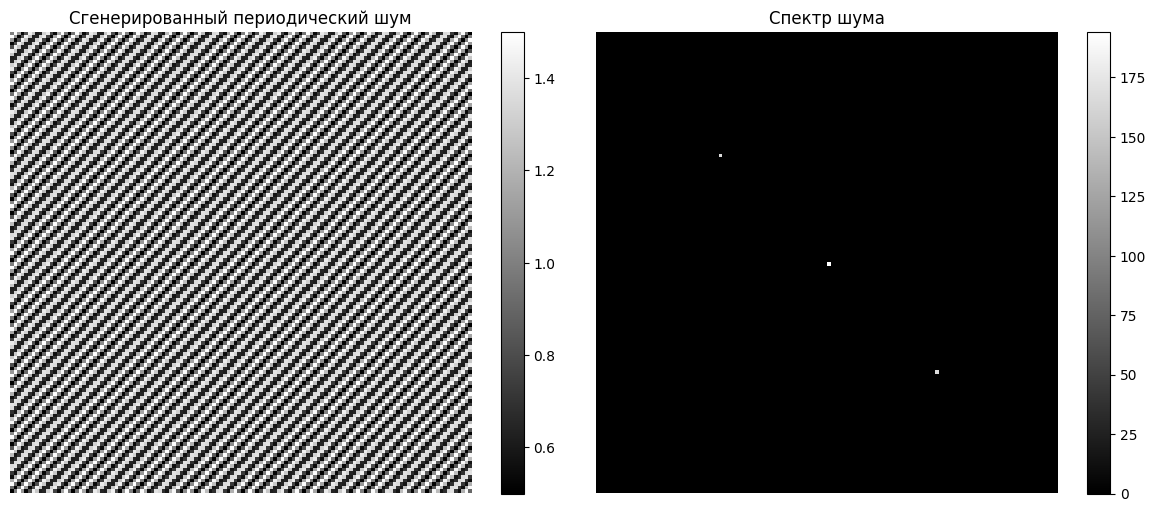


Фильтрация периодического шума...


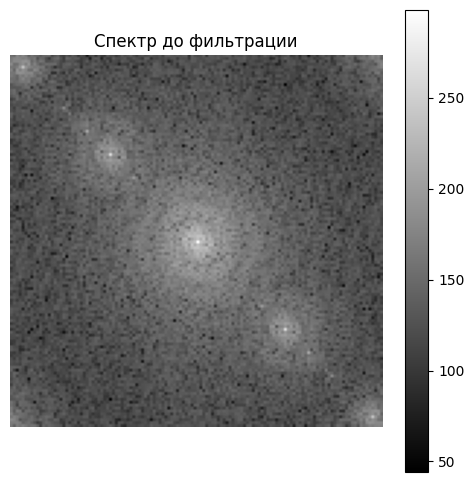

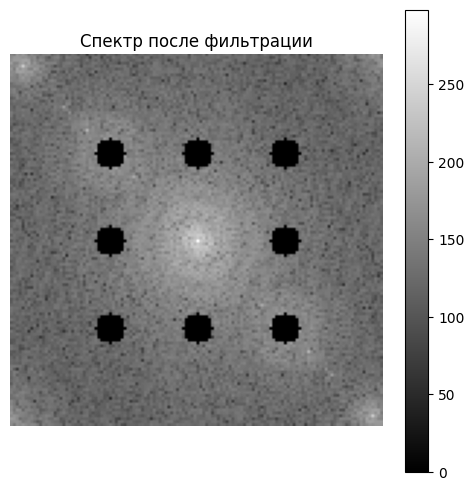


Результаты обработки:


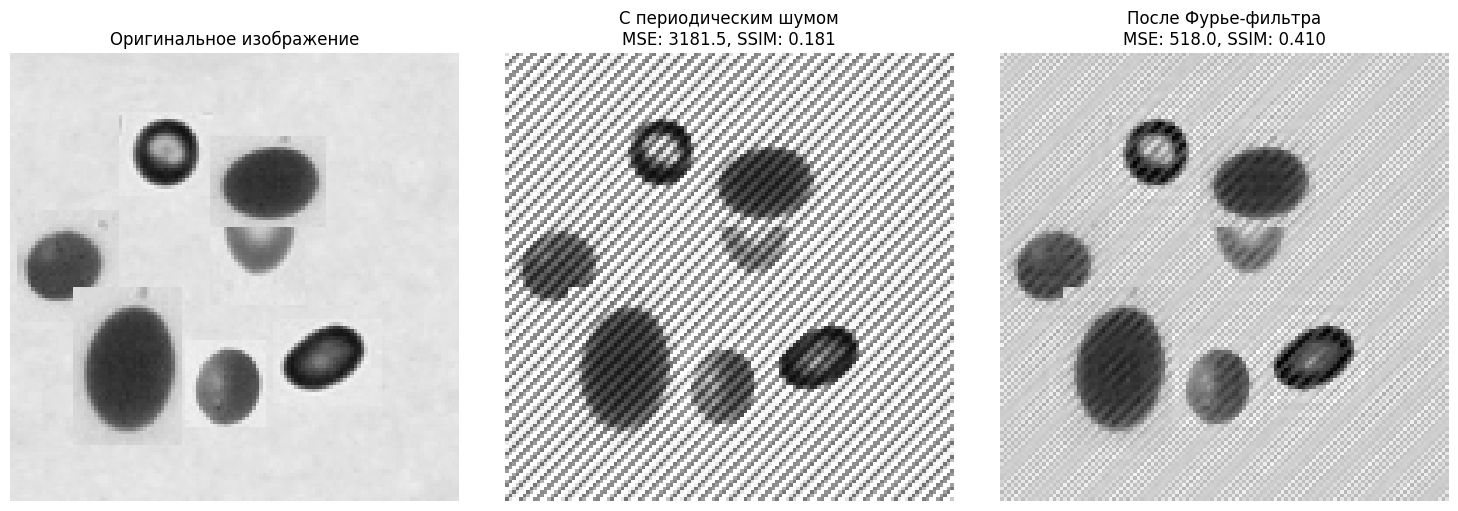

In [8]:
import os
import random
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.metrics import mean_squared_error, structural_similarity

image_path = "/Users/zuhroabdulloeva/Desktop/4 КУРС/cv/image.png" 

PATCH_SIZE = (64, 64)
IMAGE_SIZE = (512, 512)
NUM_CELLS_RANGE = (2, 10)

def generate_and_visualize_noise(image_shape, freq=30, amplitude=0.5):
    x = np.arange(0, image_shape[1])
    y = np.arange(0, image_shape[0])
    xx, yy = np.meshgrid(x, y)

    noise = 1 + amplitude * np.sin(2 * np.pi * freq * xx / image_shape[1] +
                                 2 * np.pi * freq * yy / image_shape[0])


    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(noise, cmap='gray')
    plt.title('Сгенерированный периодический шум')
    plt.colorbar()
    plt.axis('off')

    noise_spectrum = np.fft.fft2(noise)
    noise_spectrum_shift = np.fft.fftshift(noise_spectrum)
    magnitude_spectrum = 20 * np.log(np.abs(noise_spectrum_shift) + 1)

    plt.subplot(1, 2, 2)
    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title('Спектр шума')
    plt.colorbar()
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return noise

# добавление периодического шума 
def add_periodic_noise(image, freq=30, amplitude=0.5):
    noise = generate_and_visualize_noise(image.shape[:2], freq, amplitude)
    noisy_image = image.astype(np.float32) * noise[:, :, np.newaxis]
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

# визуализация фурье-спектра изображения
def plot_spectrum(image, title):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    dft = np.fft.fft2(gray)
    dft_shift = np.fft.fftshift(dft)
    magnitude_spectrum = 20 * np.log(np.abs(dft_shift) + 1)

    plt.figure(figsize=(6, 6))
    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title(title)
    plt.colorbar()
    plt.axis('off')
    plt.show()

# Функция для удаления периодического шума с помощью Фурье
def remove_periodic_noise(image, freq=30):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # фурье-преобразование
    dft = np.fft.fft2(gray)
    dft_shift = np.fft.fftshift(dft)
    # визуализация спектра до фильтрации
    plot_spectrum(image, "Спектр до фильтрации")
    # маска для фильтрации
    rows, cols = gray.shape
    crow, ccol = rows // 2, cols // 2
    mask = np.ones((rows, cols), np.uint8)
    # удаление высокочастотных компонент (периодический шум)
    radius = 5
    for i in range(-1, 2):
        for j in range(-1, 2):
            if i == 0 and j == 0:
                continue
            cv2.circle(mask, (ccol + i*freq, crow + j*freq), radius, 0, -1)
            cv2.circle(mask, (ccol - i*freq, crow - j*freq), radius, 0, -1)

    # применение маски
    fshift = dft_shift * mask
    # визуализация спектра после фильтрации
    plt.figure(figsize=(6, 6))
    plt.imshow(20 * np.log(np.abs(fshift) + 1), cmap='gray')
    plt.title("Спектр после фильтрации")
    plt.colorbar()
    plt.axis('off')
    plt.show()

    f_ishift = np.fft.ifftshift(fshift)
    img_back = np.fft.ifft2(f_ishift)
    restored = np.abs(img_back)

    restored = cv2.normalize(restored, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return cv2.cvtColor(restored, cv2.COLOR_GRAY2BGR)

def calculate_metrics(original, processed):
    original_gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    processed_gray = cv2.cvtColor(processed, cv2.COLOR_BGR2GRAY)

    mse = mean_squared_error(original_gray, processed_gray)
    ssim = structural_similarity(original_gray, processed_gray)

    return mse, ssim

if __name__ == "__main__":
    print("Загрузка изображения...")
    image = cv2.imread(image_path)

    if image is None: 
        raise ValueError(f"Не удалось загрузить изображение по пути {image_path}!")

    print("\nДобавление периодического шума...")
    noisy_periodic = add_periodic_noise(image.copy())  

    print("\nФильтрация периодического шума...")
    restored_image = remove_periodic_noise(noisy_periodic.copy())

    mse_periodic, ssim_periodic = calculate_metrics(image, noisy_periodic) 
    mse_restored, ssim_restored = calculate_metrics(image, restored_image)

    print("\nРезультаты обработки:")
    plt.figure(figsize=(15, 5))

    plt.subplot(131), plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)) 
    plt.title('Оригинальное изображение'), plt.axis('off')

    plt.subplot(132), plt.imshow(cv2.cvtColor(noisy_periodic, cv2.COLOR_BGR2RGB))
    plt.title(f'С периодическим шумом\nMSE: {mse_periodic:.1f}, SSIM: {ssim_periodic:.3f}'), plt.axis('off')

    plt.subplot(133), plt.imshow(cv2.cvtColor(restored_image, cv2.COLOR_BGR2RGB))
    plt.title(f'Восстановленное изображение\nMSE: {mse_restored:.1f}, SSIM: {ssim_restored:.3f}'), plt.axis('off')

    plt.tight_layout()
    plt.show()